# Самостоятельная работа: GBDT для задачи Traffic & Mobility на геоданных Санкт-Петербурга

## Тема
**Оценка потенциальной транспортной нагрузки на сегменты уличной сети Санкт-Петербурга** с использованием геометрических и пространственных признаков.

В этом ноутбуке вам нужно самостоятельно завершить пайплайн машинного обучения:

1. загрузить реальные геоданные из OpenStreetMap;
2. подготовить геометрию дорожных сегментов;
3. извлечь геометрические признаки;
4. добавить признаки городского окружения;
5. сформировать целевую переменную-прокси;
6. обучить модель GBDT;
7. оценить качество модели;
8. визуализировать прогноз на карте.

> Важно: это учебная задача. Мы не используем реальные датчики трафика, поэтому целевая переменная будет **прокси-показателем транспортной нагрузки**. В реальных проектах её можно заменить на данные с детекторов, GPS-треков, скорости движения, ДТП или общественного транспорта.

## 0. Установка и импорт библиотек

Запустите ячейку ниже. Если часть библиотек не установлена, раскомментируйте установку.

In [1]:
# !pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

## 1. Область исследования

Используем bbox для центральной части Санкт-Петербурга. При желании можно изменить границы, но слишком большая область будет долго загружаться.

Формат bbox: `(west, south, east, north)`.

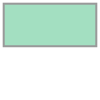

In [2]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

polygon_wgs

## 2. Загрузка уличной сети из OpenStreetMap

В этой части нужно загрузить граф автомобильной дорожной сети и преобразовать его в GeoDataFrame с рёбрами.

### Задание 1
Заполните пропуски `...` так, чтобы:

- загрузить граф дорог через `ox.graph_from_polygon`;
- использовать тип сети `drive`;
- получить таблицу рёбер через `ox.graph_to_gdfs`.

In [3]:
import requests
from urllib.parse import urlencode

base_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download?"

url_paths = [("https://disk.yandex.ru/d/HOy2QMaGAxOkFw", "spb_center_stops.osm"),
            ("https://disk.yandex.ru/d/K_nDzJS5LGgLVw", "spb_center_pois.osm"),
            ("https://disk.yandex.ru/d/oZ2MOqT3XSXMyw", "spb_center_roades_main_plus_local.osm")]

for public_url, local_path in url_paths:

    final_url = base_url + urlencode(dict(public_key=public_url))

    resp = requests.get(final_url)
    resp.raise_for_status()
    download_url = resp.json()["href"]  # прямая ссылка на файл или zip
    print("Download URL:", download_url)
    
    file_resp = requests.get(download_url, stream=True)
    file_resp.raise_for_status()

    with open(local_path, "wb") as f:
        for chunk in file_resp.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
    print("Скачано в", local_path)

Download URL: https://downloader.disk.yandex.ru/disk/def236c86b2d1e6be434da3406a9ec8343827215b335cb5f9fe50da8a0641c3d/6a2008b6/Vjgkf5jrb6nxXREsNTc4QiWoWfu9gaDtHCaWSzu_kmUPvkBzKLiPZ87e2jSptmq3x3rLZrmy86Lwpr8HOqLt7g%3D%3D?uid=0&filename=spb_center_stops.osm&disposition=attachment&hash=oAgIUTmhFVaEKsazV%2BaHLF7jxSniW3MrsF%2B0OTqz/Evh6%2BUu7GMzxj1uAf/sAHufq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=text%2Fxml&owner_uid=34728467&fsize=3011894&hid=1ea2cb55394bfe33967c51caeec4b7f3&media_type=document&tknv=v3&is_direct_zip_experiment=1
Скачано в spb_center_stops.osm
Download URL: https://downloader.disk.yandex.ru/disk/0668102b0845f4e8c57dd9de3491b1747126522d0567f9fb8c68e3d24e83df40/6a2008b8/Vjgkf5jrb6nxXREsNTc4QqtA0yYPNBLJIDj3u9BYQHYAqQBLtzSllBsi6oNswW8lmTw7_Z3C-Z_KXt3GuLtzrQ%3D%3D?uid=0&filename=spb_center_pois.osm&disposition=attachment&hash=LqDHKWWshkXzQecVQgqMlSXjo6B7Z%2BbyoI5MY8gtevrwnoUzvXsp5B8GA/aKtabAq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=text%2Fxml&owner_uid=347

In [4]:
G = ox.graph_from_xml("spb_center_roades_main_plus_local.osm")
nodes, edges = ox.graph_to_gdfs(G)

print(edges.shape)
edges.head()

(16413, 16)


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access service  
u      v          key                                                   
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN     NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN     NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN     NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN     NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN     NaN

## 3. Приведение к метрической системе координат

Для расстояний, длин и площадей нельзя использовать градусы широты/долготы. Нужно перейти в метрическую проекцию.

Для Санкт-Петербурга можно использовать, например, `EPSG:32636`.

### Задание 2
Создайте копию `edges_m`, переведённую в метрическую CRS.

In [5]:
# TODO: переведите дороги в метрическую CRS
edges_m = edges.to_crs(epsg=32636)

# Проверка
edges_m.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 4. Базовые геометрические признаки дорожных сегментов

Для каждого сегмента дороги можно извлечь признаки из его геометрии:

- длина сегмента;
- координаты центроида;
- прямое расстояние между началом и концом линии;
- извилистость;
- направление сегмента.

### Задание 3
Допишите вычисление признаков.

In [6]:
roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Функция для прямого расстояния между началом и концом LineString
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)  # евклидово расстояние

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги в радианах
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)
roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16413.000000,16413.000000,16413.000000,16413.000000
mean,188.135425,181.653553,1.045162,0.001922
std,250.348976,237.152670,0.890473,1.817557
min,1.236514,0.000000,1.000000,-3.141433
25%,29.007419,27.950085,1.000000,-1.582539
50%,108.535401,106.464686,1.000019,0.000000
75%,253.466708,246.690336,1.002736,1.555100
max,5072.585972,4987.745925,76.797540,3.140873


## 5. Категориальные признаки дороги

В OSM у дорог есть тег `highway`: motorway, primary, secondary, tertiary, residential и т.д.

GBDT в `scikit-learn` обычно работает с числовыми признаками, поэтому категориальные признаки нужно закодировать.

### Задание 4
Сделайте one-hot encoding для признака `highway`.

Подсказка: иногда `highway` может быть списком. Код ниже уже приводит его к строке.

In [7]:
roads["highway_str"] = roads["highway"].apply(
    lambda x: ",".join(x) if isinstance(x, list) else str(x)
)

# TODO: создайте dummy-переменные для highway_str
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

roads = pd.concat([roads, highway_dummies], axis=1)

highway_dummies.head()

highway_living_street  highway_motorway  \
u      v          key                                            
219808 2327840    0                    False             False   
       389449562  0                    False             False   
219811 1832085962 0                    False             False   
       1465050831 0                    False             False   
219812 249890545  0                    False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  highway_residential  \
u      v          key                                                      
219808 2327840    0                           False                False   
       389449562  0                           False                False   
219811 1832085962 0                           False                False   
       1465050831 0                           False                False   
219812 249890545  0                           False                False   

                       highway_residential,living_street  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_residential,primary_link  \
u      v          key                                     
219808 2327840    0                               False   
       389449562  0                               False   
219811 1832085962 0                               False   
       1465050831 0                               False   
219812 249890545  0                               False   

                       highway_residential,tertiary  \
u      v          key                                 
219808 2327840    0                           False   
       389449562  0                           False   
219811 1832085962 0                           False   
       1465050831 0                           False   
219812 249890545  0                           False   

                       highway_residential,unclassified  highway_secondary  \
u      v          key                                                        
219808 2327840    0                               False              False   
       389449562  0                               False              False   
219811 1832085962 0                               False              False   
       1465050831 0                               False              False   
219812 249890545  0                               False              False   

                       highway_secondary_link  \
u      v          key                           
219808 2327840    0                     False   
       389449562  0                     False   
219811 1832085962 0                     False   
       1465050831 0                     False   
219812 249890545  0                     False   

                       highway_secondary_link,secondary  highway_tertiary  \
u      v          key                                                       
219808 2327840    0                               False             False   
       389449562  0                               False             False   
219811 1832085962 0                               False             False   
       1465050831 0                               False             False   
2198

## 6. Загрузка POI и остановок общественного транспорта

Теперь добавим признаки окружения дороги:

- расстояние до ближайшего POI;
- расстояние до ближайшей остановки;
- количество POI в радиусе 300 м;
- количество остановок в радиусе 300 м.

### Задание 5
Загрузите POI и остановки из OSM.

In [8]:
pois = gpd.read_file("spb_center_pois.osm")

pois = pois[pois.geometry.type == "Point"].set_crs(epsg=4326)

print("POI:", pois.shape)
pois.head()

POI: (76309, 11)


,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
0,223749,None,None,None,None,None,None,None,None,"""amenity""=>""ferry_terminal"",""ferry""=>""yes"",""pu...",POINT (29.77056 59.98477)
1,29001764,None,None,None,None,None,None,None,None,"""amenity""=>""ferry_terminal"",""railway""=>""ferry_...",POINT (30.26151 59.9194)
2,248465159,Фитнес,None,None,None,None,None,None,None,"""contact:email""=>""fclub-spb@yandex.ru"",""contac...",POINT (30.41156 60.01199)
3,248465166,Всё для дома,None,None,None,None,None,None,None,"""shop""=>""yes""",POINT (30.41217 60.01255)
4,248701411,None,None,None,None,None,None,None,None,"""service""=>""tyres"",""shop""=>""car_repair""",POINT (30.3858 60.0073)


In [9]:
stops = gpd.read_file("spb_center_stops.osm")
stops = stops[stops.geometry.type == "Point"].set_crs(epsg=4326)

print("Stops:", stops.shape)
stops.head()

Stops: (7267, 11)


,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
0,223641,Биржевая площадь,None,None,None,None,None,None,None,"""bus""=>""yes"",""name:ru""=>""Биржевая площадь"",""pu...",POINT (30.30553 59.94412)
1,223749,None,None,None,None,None,None,None,None,"""amenity""=>""ferry_terminal"",""ferry""=>""yes"",""pu...",POINT (29.77056 59.98477)
2,230253,Феодосийская улица,None,None,None,None,None,None,None,"""bus""=>""yes"",""public_transport""=>""stop_position""",POINT (30.39443 59.95945)
3,258978,"проспект Энергетиков, угол Магнитогорской улицы",None,None,None,None,None,None,None,"""bus""=>""yes"",""public_transport""=>""stop_positio...",POINT (30.43508 59.93932)
4,259179,Байконурская улица,None,None,None,None,None,None,None,"""bus""=>""yes"",""public_transport""=>""stop_positio...",POINT (30.27535 59.99867)


## 7. Подготовка точек POI и остановок

OSM-объекты могут быть точками, линиями и полигонами. Для расчёта расстояний удобно заменить каждую геометрию на точку-представитель.

### Задание 6
Переведите POI и остановки в метрическую CRS и создайте центроиды/representative points.

In [10]:
def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    # representative_point гарантирует точку внутри полигона
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

# TODO: примените функцию к pois и stops
pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

,osm_id,name,barrier,highway,ref,address,is_in,place,man_made,other_tags,geometry
0,223749,None,None,None,None,None,None,None,None,"""amenity""=>""ferry_terminal"",""ferry""=>""yes"",""pu...",POINT (319834.245 6654113.884)
1,29001764,None,None,None,None,None,None,None,None,"""amenity""=>""ferry_terminal"",""railway""=>""ferry_...",POINT (346911.245 6645602.235)
2,248465159,Фитнес,None,None,None,None,None,None,None,"""contact:email""=>""fclub-spb@yandex.ru"",""contac...",POINT (355699.365 6655570.419)
3,248465166,Всё для дома,None,None,None,None,None,None,None,"""shop""=>""yes""",POINT (355735.863 6655631.331)
4,248701411,None,None,None,None,None,None,None,None,"""service""=>""tyres"",""shop""=>""car_repair""",POINT (354243.62 6655104.647)


## 8. Пространственные признаки через BallTree

Создадим функцию, которая для каждой дороги считает:

- расстояние от центроида дороги до ближайшего объекта;
- количество объектов в заданном радиусе.

### Задание 7
Допишите функцию `nearest_and_count`.

In [11]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    """
    source_gdf: объекты, для которых считаем признаки, например дороги
    target_gdf: объекты окружения, например POI или остановки
    radius: радиус поиска в метрах
    """
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    # TODO: расстояние до ближайшего объекта
    dist, ind = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    # TODO: количество объектов в радиусе
    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Для расчётов используем центроиды дорог как точки
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16413.000000,16413.000000,16413.000000,16413.000000
mean,64.375763,114.708280,144.176491,9.485956
std,86.429198,121.047146,142.095161,7.137708
min,0.293001,0.000000,0.160834,0.000000
25%,22.258862,30.000000,49.135468,4.000000
50%,41.026927,72.000000,105.029413,8.000000
75%,72.873122,161.000000,194.505938,13.000000
max,2118.620170,867.000000,1891.422676,51.000000


## 9. Графовые признаки дорожной сети

Для Traffic & Mobility важна не только геометрия, но и положение сегмента в графе улиц.

Добавим простой графовый признак: средняя степень начального и конечного узла дороги.

### Задание 8
Используйте `G.degree()` и индексы рёбер, чтобы посчитать степень узлов `u` и `v`.

In [12]:
# В edges/roads индекс обычно MultiIndex: u, v, key
roads = roads.reset_index()

# TODO: словарь степеней узлов
node_degree = dict(G.degree())

roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16413.000000,16413.000000,16413.000000
mean,4.427283,4.425212,4.426247
std,1.331815,1.334625,1.087940
min,1.000000,1.000000,2.000000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


## 10. Формирование учебной целевой переменной

Так как у нас нет реальных измерений трафика, создадим прокси-показатель `traffic_load_score`.

Идея:

- более длинные и крупные дороги могут иметь большую нагрузку;
- близость к POI повышает потенциальный спрос;
- близость к остановкам повышает мультимодальную активность;
- высокая связность узлов может означать важное положение в сети.

### Задание 9
Доделайте формулу целевой переменной.

Подумайте: какие признаки должны увеличивать нагрузку, а какие уменьшать?

In [13]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

roads["length_norm"] = minmax(
    roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99))
)
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(
    roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99))
)
roads["near_stop_norm"] = 1 - minmax(
    roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99))
)

rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# TODO: придумайте веса компонентов
roads["traffic_load_score"] = (
    0.25 * roads["length_norm"] +
    0.2  * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.15 * roads["near_poi_norm"] +
    0.1  * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

count    16413.000000
mean         0.361633
std          0.091581
min          0.000000
25%          0.303340
50%          0.361541
75%          0.421566
max          0.727716
Name: traffic_load_score, dtype: float64

## 11. Подготовка признаков для модели

Теперь соберите список признаков.

### Задание 10
Добавьте в `feature_cols` числовые признаки, которые вы считаете полезными.

Не включайте в признаки:

- `geometry`;
- целевую переменную `traffic_load_score`;
- служебные текстовые поля OSM.

In [14]:
base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

highway_features = list(highway_dummies.columns)

# TODO: объедините списки признаков
feature_cols = base_features + highway_features

X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X.shape, y.shape

((16413, 31), (16413,))

## 12. Разделение на train/test

### Задание 11
Разделите данные на обучающую и тестовую выборки.

In [15]:
# TODO: используйте train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((12309, 31), (4104, 31))

## 13. Обучение GBDT-модели

Используйте реализации GB, как LightGBM / XGBoost / CatBoost

### Задание 12
Создайте и обучите модели.

In [16]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}:")
    print(f"  MAE  = {mae:.6f}")
    print(f"  RMSE = {rmse:.6f}")
    print(f"  R2   = {r2:.6f}")
    print("-" * 40)
    return model, mae, rmse, r2

In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [6, 8, 10],
    "learning_rate": [0.05, 0.1],
    "max_iter": [150, 200, 300],
    "min_samples_leaf": [20, 50]
}

gbrt = HistGradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    gbrt,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV score (MSE):", -grid_search.best_score_)

best_hist_gbrt_model = grid_search.best_estimator_

best_hist_gbrt_model, best_mae, best_rmse, best_r2 = evaluate_model(
    "Tuned HistGBRT", best_hist_gbrt_model, X_train, y_train, X_test, y_test
)

Best params: {'learning_rate': 0.05, 'max_depth': 6, 'max_iter': 150, 'min_samples_leaf': 50}
Best CV score (MSE): 0.002668041446671444
Tuned HistGBRT:
  MAE  = 0.041137
  RMSE = 0.051569
  R2   = 0.676701
----------------------------------------


In [18]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    n_jobs=-1,
    random_state=42,
    tree_method="hist",    
)

xgb_param_dist = {
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_lambda": [0.0, 1.0, 3.0],
    "gamma": [0.0, 0.5, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=30,         
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

xgb_search.fit(X_train, y_train)

print("XGBRegressor best params:", xgb_search.best_params_)
print("XGBRegressor best CV MSE:", -xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_

xgb_best_model, xgb_best_mae, xgb_best_rmse, xgb_best_r2 = evaluate_model(
    "XGBRegressor", xgb_best, X_train, y_train, X_test, y_test
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
XGBRegressor best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.0, 'colsample_bytree': 0.7}
XGBRegressor best CV MSE: 0.0026759248269616755
XGBRegressor:
  MAE  = 0.040957
  RMSE = 0.051401
  R2   = 0.678799
----------------------------------------


In [19]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

cat_param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1.0, 3.0, 5.0],
}

cat_grid = GridSearchCV(
    estimator=cat_model,
    param_grid=cat_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

cat_grid.fit(X_train, y_train)

print("CatBoost best params:", cat_grid.best_params_)
print("CatBoost best CV MSE:", -cat_grid.best_score_)

cat_best = cat_grid.best_estimator_

cat_best_model, cat_best_mae, cat_best_rmse, cat_best_r2 = evaluate_model(
    "Tuned CatBoost", cat_best, X_train, y_train, X_test, y_test
)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
CatBoost best params: {'depth': 4, 'iterations': 500, 'l2_leaf_reg': 3.0, 'learning_rate': 0.03}
CatBoost best CV MSE: 0.002573465441296323
Tuned CatBoost:
  MAE  = 0.040252
  RMSE = 0.050598
  R2   = 0.688760
----------------------------------------


## 14. Оценка качества

### Задание 13

Посчитайте метрики для каждой модели:

- MAE;
- RMSE;

### Заданиче 14

Выберите лучшую модель как baseline и попробуйте (насколько это возможно) настроить гиперпараметры для определения оптимальной инициализации модели

## 16. Прогноз для всех дорожных сегментов и карта

Теперь примените полученную на предыдущем этапе модель ко всем дорогам и визуализируйте результат.

### Задание 15
Создайте столбец `predicted_traffic_load` и постройте карту.

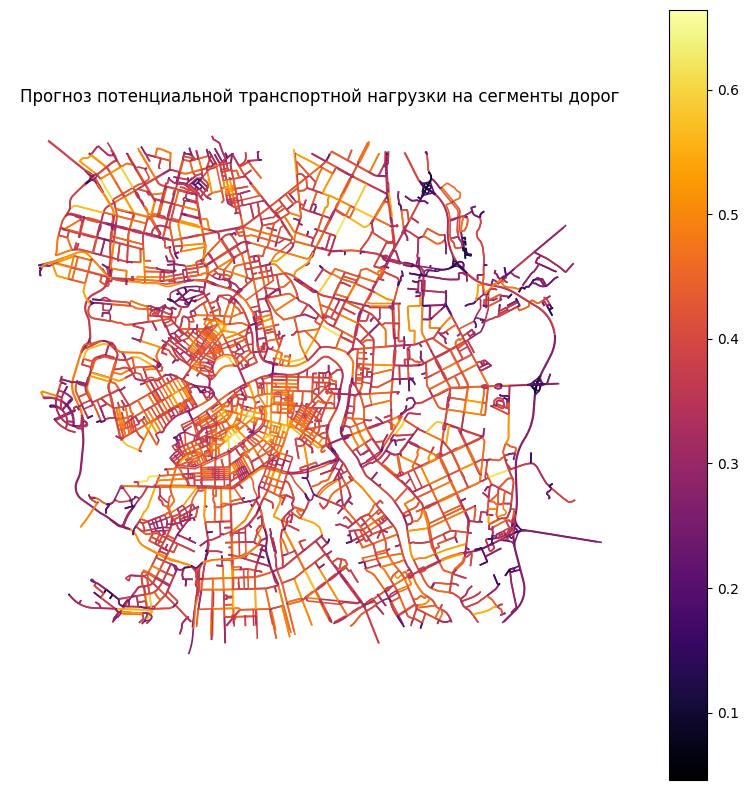

In [20]:
best_model = cat_best_model

# TODO: прогноз для всех сегментов
roads["predicted_traffic_load"] = best_model.predict(
    roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
)

# Возвращаем геометрию в WGS84 для удобной визуализации
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(10, 10))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="inferno"
)
ax.set_title("Прогноз потенциальной транспортной нагрузки на сегменты дорог")
ax.set_axis_off()
plt.show()